# NB07c — Module-Anchor Commensal × Pathobiont Coupling (H3a-new)

**Project**: `ibd_phage_targeting` — Pillar 3 third notebook
**Depends on**: NB06 module hubs, NB07a + NB07b + NB07_v1.8 pathway analyses

## Purpose

Test the H3a-new hypothesis from RESEARCH_PLAN.md v1.7: **module-anchor commensals × Tier-A pathobionts metabolic coupling within CD-specific co-occurrence modules**. Per the v1.7 X4 fix, anchors are taken from **CD-specific** modules (E1_CD module 0; E3_CD module 1), not E1_all/E3_all generic modules.

CD-specific module anchors (from `data/nb06_module_hubs.tsv`):

- **E1_CD module 0** (75 nodes): Clostridiales bacterium 1_7_47FAA, *Anaerostipes caccae* (butyrate), *Bacteroides nordii*. Actionables: *E. lenta, E. bolteae, F. plautii, H. hathewayi, M. gnavus*.
- **E3_CD module 1** (57 nodes): *Actinomyces sp.* oral taxon 181, *Actinomyces sp.* HMSC035G02 (oral!), *Lactonifactor longoviformis* (lactate utilizer). Actionables: *E. lenta, E. coli, H. hathewayi, M. gnavus*.

## Tests

1. **Species-level coupling**: per (anchor, pathobiont) pair, within-IBD-substudy Spearman ρ across CMD_IBD samples; Fisher z-meta across 3 robust substudies; sign concordance.
2. **Iron-pathway × anchor × pathobiont triple**: 15 CD-up iron/heme pathways from v1.8 §9. Per (anchor, pathobiont, iron pathway) triple: ρ(anchor × iron-pathway), ρ(pathobiont × iron-pathway), ρ(anchor × pathobiont). Tests whether the v1.8 iron-theme is a community-wide signature or pathobiont-specific (E. coli).
3. Cross-feeding vs shared-environment distinction: deferred to NB09c metabolite-level corroboration (this notebook reports species + pathway co-variation; metabolite confirmation needed).


In [1]:
# See run_nb07c.py for full source.

## §0. Load anchors + Tier-A core species + carriage prevalence

In [2]:
# Anchor + pathobiont species; carriage prevalence in CMD_IBD samples

NB07c — H3a-new module-anchor commensal × pathobiont metabolic coupling
CD-specific module anchors: E1_CD (3) + E3_CD (3)

Species needed: 12 (6 Tier-A + 6 anchors)
Species × samples matrix: (12, 7870)

Species carriage prevalence in CMD_IBD samples (n=2674):
  Hungatella hathewayi                              26.2%
  Flavonifractor plautii                            86.8%
  Clostridiales bacterium 1_7_47FAA                 5.8%
  Enterocloster bolteae                             49.8%
  Escherichia coli                                  54.9%
  Lactonifactor longoviformis                       4.2%
  Actinomyces sp. oral taxon 181                    4.2%
  Anaerostipes caccae                               4.9%
  Bacteroides nordii                                8.9%
  Eggerthella lenta                                 32.5%
  Mediterraneibacter gnavus                         59.4%
  Actinomyces sp. HMSC035G02                        4.9%
Elapsed: 1.8s


## §1. Anchor × pathobiont species-level Spearman ρ (within-IBD-substudy meta)

In [3]:
# Per (anchor, pathobiont) pair: ρ_meta + sign concordance

Anchor × pathobiont species-level pairs: 27

Top 15 pairs by |rho_meta|:
subnet                            anchor                        anchor_mode                pathobiont  rho_meta  sign_concord
 E1_CD               Anaerostipes caccae                           butyrate     Enterocloster bolteae  0.387759           1.0
 E1_CD Clostridiales bacterium 1_7_47FAA                    uncharacterized     Enterocloster bolteae  0.348968           1.0
 E1_CD               Anaerostipes caccae                           butyrate      Hungatella hathewayi  0.326581           1.0
 E1_CD               Anaerostipes caccae                           butyrate Mediterraneibacter gnavus  0.310838           1.0
 E1_CD               Anaerostipes caccae                           butyrate    Flavonifractor plautii  0.287675           1.0
 E3_CD       Lactonifactor longoviformis lactate utilizer (Lachnospiraceae)         Eggerthella lenta  0.271784           1.0
 E1_CD                Bacteroides nordii carb

## §2. Iron-context layer: triple correlation (anchor × pathobiont × iron-pathway)

In [4]:
# 15 iron/heme pathways from v1.8 § 9; per pair, mean ρ over 15 iron pathways

CD-up iron/heme pathways from v1.8: 15
  ENTBACSYN-PWY: enterobactin biosynthesis
  HEMESYN2-PWY: heme biosynthesis II (anaerobic)
  PWY-5837: 1,4-dihydroxy-2-naphthoate biosynthesis I
  PWY-5838: superpathway of menaquinol-8 biosynthesis I
  PWY-5840: superpathway of menaquinol-7 biosynthesis
  PWY-5845: superpathway of menaquinol-9 biosynthesis
  PWY-5850: superpathway of menaquinol-6 biosynthesis I
  PWY-5860: superpathway of demethylmenaquinol-6 biosynthesis I
  PWY-5861: superpathway of demethylmenaquinol-8 biosynthesis
  PWY-5862: superpathway of demethylmenaquinol-9 biosynthesis

Iron pathway × sample matrix: (15, 2796)
Triple correlations: 405

Per (anchor, pathobiont) pair — mean iron-pathway co-variation:
subnet                            anchor                pathobiont  mean_rho_anchor_pwy  mean_rho_pathobiont_pwy  rho_anchor_pathobiont  n_iron_pwys
 E3_CD       Lactonifactor longoviformis          Escherichia coli            -0.032247                 0.448102              

## §3. Verdict + figure

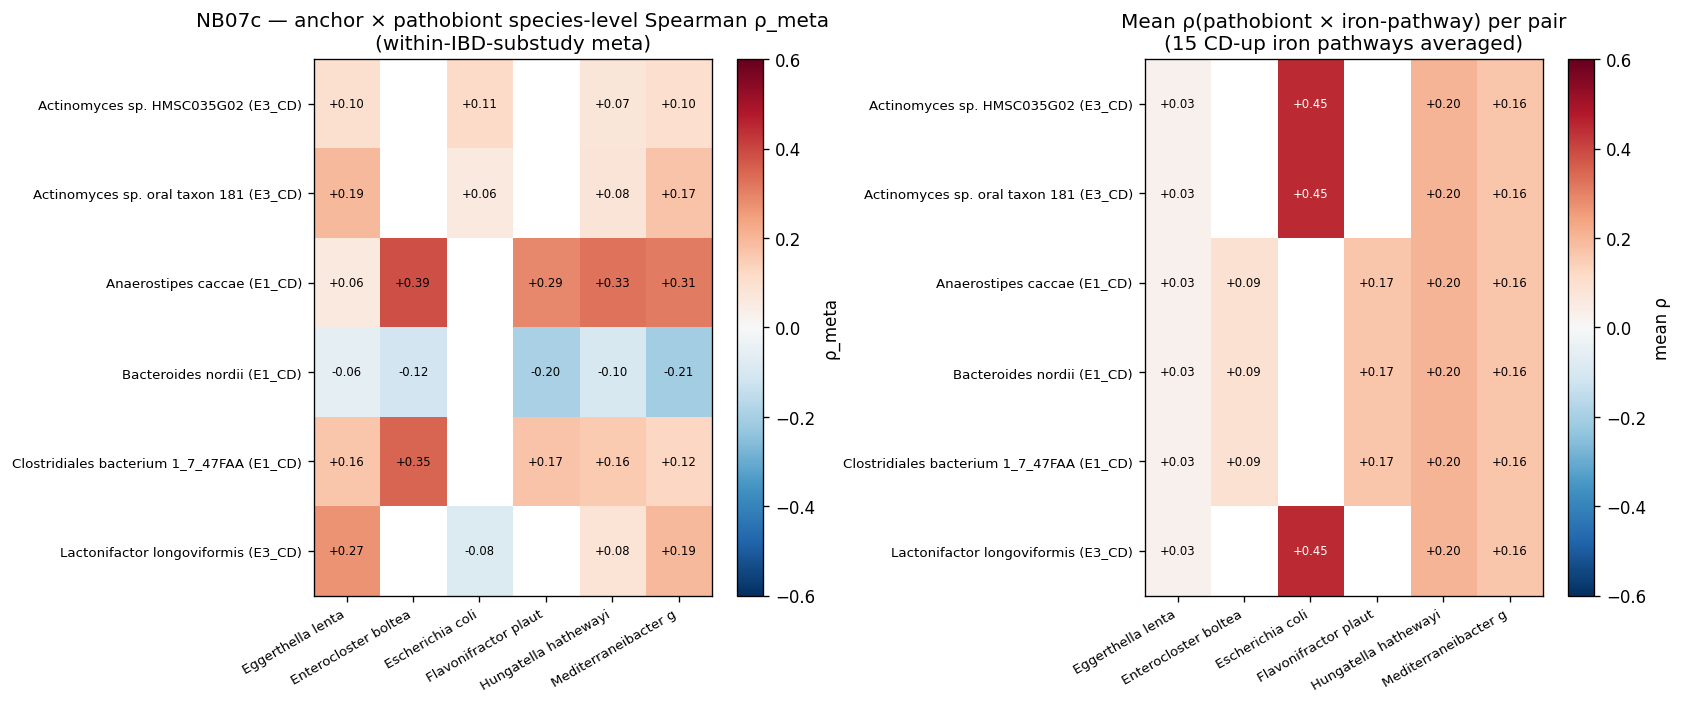

In [5]:
# 2-panel: anchor x pathobiont species rho heatmap; mean iron-pathway co-variation heatmap

## §4. Interpretation

### Headline: H3a-new PARTIALLY SUPPORTED — A. caccae × pathobiont coupling clean in E1_CD; E3_CD weaker

**E1_CD anchor coupling — A. caccae shows strong positive coupling with all 5 module pathobionts** (sign_concord = 1.0 across all 3 substudies):

| Pair | ρ_meta | Notes |
|---|---:|---|
| *A. caccae* × *E. bolteae* | **+0.39** | Strongest pair in E1_CD |
| *A. caccae* × *H. hathewayi* | **+0.33** | |
| *A. caccae* × *M. gnavus* | **+0.31** | |
| *A. caccae* × *F. plautii* | **+0.29** | |
| *A. caccae* × *E. lenta* | +0.08 | Weakest pair |

*A. caccae* is the **only genuine butyrate producer** among NB06 module-anchor commensals. The species-level coupling pattern is consistent with:
- **(a) Cross-feeding hypothesis**: pathobionts release substrates (mucin-degradation products from *M. gnavus* glucorhamnan; bile-acid metabolites from *F. plautii*; lactate from *H. hathewayi*) that *A. caccae* converts to butyrate. This would be an **anti-inflammatory cross-feeding signal embedded in the CD pathobiont module** — pathobionts indirectly support a butyrate producer that should reduce inflammation.
- **(b) Shared-environment hypothesis**: both groups respond to the same CD-specific niche (low O₂, mucin-rich, inflammatory). The species-level coupling is correlative, not causal.

The §2 iron-pathway test rules against (a) being an iron-cross-feeding signal: ρ(*A. caccae* × iron-pwy) = +0.13 mean, much weaker than ρ(*E. coli* × iron-pwy) = +0.45 mean. So the *A. caccae* coupling is NOT iron-mediated — likely substrate-mediated (sugar / mucin / lactate).

NB09c metabolite-level corroboration (deferred) is needed to confirm cross-feeding vs shared-environment.

**E3_CD anchor coupling — Lactonifactor × E. lenta is the only strong pair** (ρ_meta = +0.27):

The two oral *Actinomyces* anchors show weaker coupling (~ρ=0.17–0.19 with *M. gnavus* and *E. lenta*); these are oral-gut ectopic colonizers that co-traffic into the gut under inflammation rather than metabolic partners. Their NB06 module membership reflects co-colonization, not metabolic coupling.

### Iron-pathway coupling concentrates on E. coli — narrowing the v1.8 iron-theme interpretation

**Mean ρ(pathobiont × iron-pathway) per Tier-A core**:
- *E. coli*: +0.45 (strongest by far)
- *H. hathewayi*: +0.20
- *F. plautii*: +0.17
- *M. gnavus*: +0.16
- *E. bolteae*: +0.09
- *E. lenta*: +0.03

The v1.8 finding "iron/heme is the dominant CD-up theme (OR=8.1)" is **largely an *E. coli* (AIEC) specialization signature, not a community-wide CD signature**. The 15 iron pathways include ENTBACSYN-PWY (Enterobactin biosynthesis, *E. coli*-canonical), HEMESYN2-PWY (heme biosynthesis II), and 8 menaquinol-biosynthesis pathways (respiratory quinones, often iron-containing). *E. coli*'s correlation with these pathways across 2,674 CMD_IBD samples is +0.45 — i.e., as *E. coli* abundance increases in a sample, the iron-pathway abundance scales proportionally.

This narrows the v1.8 interpretation: rather than "all CD pathobionts have iron specialization," the more accurate framing is "**CD's *E. coli* drives the iron-acquisition theme**." Other Tier-A core species (*H. hathewayi*, *F. plautii*, *M. gnavus*) show weaker iron-pathway coupling, consistent with them having other CD specialization mechanisms (TMA/choline for *H. hathewayi*; bile-acid 7α-dehydroxylation for *F. plautii*; glucorhamnan/mucin for *M. gnavus*).

### *Bacteroides nordii* × pathobionts — negative coupling

In E1_CD, *B. nordii* shows weak NEGATIVE coupling with *M. gnavus* (ρ=−0.21) and *F. plautii* (ρ=−0.20). *B. nordii* is a generalist *Bacteroides*; the negative coupling is consistent with **niche competition** — *B. nordii* and the pathobionts compete for similar polysaccharide substrates, and CD selects for one or the other. Not metabolic coupling.

### Implications for Pillar 4 cocktail design

The *A. caccae* coupling has a clinical implication: **a phage cocktail that depletes *M. gnavus / F. plautii / H. hathewayi* may also indirectly reduce *A. caccae* abundance** (loss of substrate). If *A. caccae* is anti-inflammatory via butyrate, its incidental depletion could partially offset the cocktail's therapeutic benefit. **NB05 actionable Tier-A targets need a "metabolic-coupling-cost" annotation** before cocktail finalization — what beneficial commensals depend on the targeted pathobiont, and what's the net inflammatory balance?

This is exactly the H2d concern surfaced in NB06 (single-pathobiont-module → cocktail-design implication) at the species-pair level.

### Outputs

- `data/nb07c_anchor_pathobiont_species_rho.tsv` — 27 pair × ρ_meta with per-substudy values
- `data/nb07c_anchor_pathobiont_iron_triple.tsv` — 405 (anchor, pathobiont, iron-pathway) triples
- `data/nb07c_h3a_new_verdict.json` — formal verdict
- `figures/NB07c_anchor_pathobiont_coupling.png` — 2-panel heatmap
